# Weather Summary Classification Project

In [35]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
import shap
import joblib
import warnings


# Data Exploration

In [36]:
df = pd.read_csv("weatherHistory.csv")

print("Shape:", df.shape)
df.head()

Shape: (96453, 11)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251,15.8263,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259,15.8263,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204,14.9569,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269,15.8263,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259,15.8263,1016.51,Partly cloudy throughout the day.


# Feature Selection & Cleaning

In [37]:
df = df[[
    "Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)",
    "Wind Bearing (degrees)",
    "Visibility (km)",
    "Pressure (millibars)",
    "Summary"
]]

df.rename(columns={"Summary": "Weather_Summary"}, inplace=True)

In [38]:
top_classes = df["Weather_Summary"].value_counts().nlargest(10).index
df = df[df["Weather_Summary"].isin(top_classes)]

# Exploratory Data Analysis

Class Distribution (Imbalance Check)

In [39]:
!pip install --upgrade nbformat

In [40]:
class_counts = df["Weather_Summary"].value_counts()

px.bar(
    x=class_counts.index,
    y=class_counts.values,
    title="Class Distribution (Imbalance Check)"
)

Correlation Heatmap

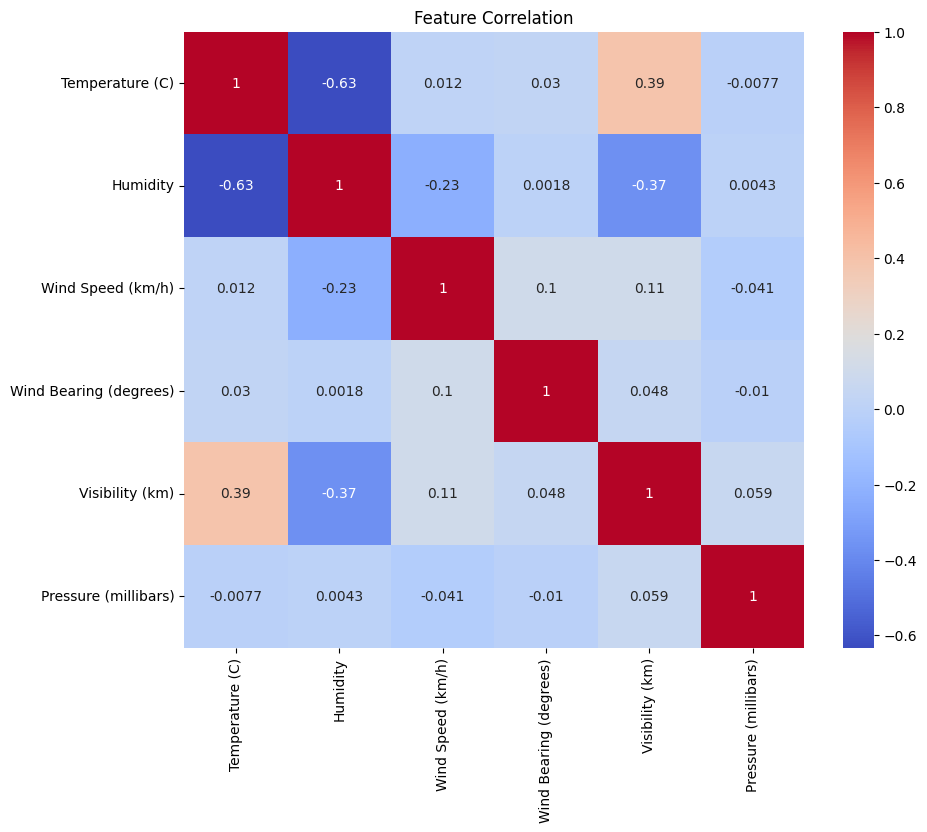

In [41]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# Data Preprocessing

Handle Missing Values

In [42]:
df.fillna(df.median(numeric_only=True), inplace=True)

Encode Target

In [43]:
le = LabelEncoder()
df["Weather_Summary"] = le.fit_transform(df["Weather_Summary"])

Feature / Target Split

In [44]:
X = df.drop("Weather_Summary", axis=1)
y = df["Weather_Summary"]

# Train-Test Split (Stratified)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 76836
Testing samples: 19209


# Handle Class Imbalance (SMOTE)

In [46]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Feature Scaling

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Cross-Validation Strategy

In [48]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter Tuning

Random Forest

In [49]:
rf_best = RandomForestClassifier(
    n_estimators=80,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_best.fit(X_train_scaled, y_train_resampled)


,n_estimators,80
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
print("Original Train Size:", X_train.shape)
print("After SMOTE:", X_train_resampled.shape)

Original Train Size: (76836, 6)
After SMOTE: (253860, 6)


Gradient Boosting

In [51]:
gb_best = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_best.fit(X_train_scaled, y_train_resampled)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [52]:
y_pred_gb = gb_best.predict(X_test_scaled)
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.49      0.37      0.42       103
           1       0.58      0.77      0.66       106
           2       0.48      0.71      0.58        77
           3       0.30      0.49      0.38      2178
           4       0.08      0.88      0.14        17
           5       1.00      1.00      1.00      1430
           6       0.46      0.29      0.36      5619
           7       0.44      0.66      0.53      3319
           8       0.56      0.46      0.50      6347
           9       1.00      1.00      1.00        13

    accuracy                           0.49     19209
   macro avg       0.54      0.66      0.56     19209
weighted avg       0.51      0.49      0.49     19209



Logistic Regression

In [53]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train_scaled, y_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Decision Tree

In [54]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=20,
    random_state=42
)

dt_model.fit(X_train_scaled, y_train_resampled)

,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Model Comparison Methodology

In [55]:
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Gradient Boosting": gb_best,   
    "Logistic Regression": lr_model,
    "Random Forest": rf_best,
    "Decision Tree": dt_model,
    
}
results=[]

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred, average="weighted")
    ])
    
    print(f"{name}")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
    print("F1-score :", f1_score(y_test, y_pred, average='weighted'))
    print("-" * 50)
    
    results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1"]
)

results_df.sort_values(by="F1", ascending=False)

Gradient Boosting
Accuracy : 0.49101983445260033
Precision: 0.5133273786459077
Recall   : 0.49101983445260033
F1-score : 0.48803324945113497
--------------------------------------------------
Logistic Regression
Accuracy : 0.4259982299963559
Precision: 0.4710878940202877
Recall   : 0.4259982299963559
F1-score : 0.4207475520170632
--------------------------------------------------
Random Forest
Accuracy : 0.5601540944349003
Precision: 0.5711786576081685
Recall   : 0.5601540944349003
F1-score : 0.5598499460475647
--------------------------------------------------
Decision Tree
Accuracy : 0.4935186631266594
Precision: 0.5103976767519401
Recall   : 0.4935186631266594
F1-score : 0.4967726257480109
--------------------------------------------------


,Model,Accuracy,Precision,Recall,F1
2,Random Forest,0.560154,0.571179,0.560154,0.559850
3,Decision Tree,0.493519,0.510398,0.493519,0.496773
0,Gradient Boosting,0.491020,0.513327,0.491020,0.488033
1,Logistic Regression,0.425998,0.471088,0.425998,0.420748


# Confusion Matrix

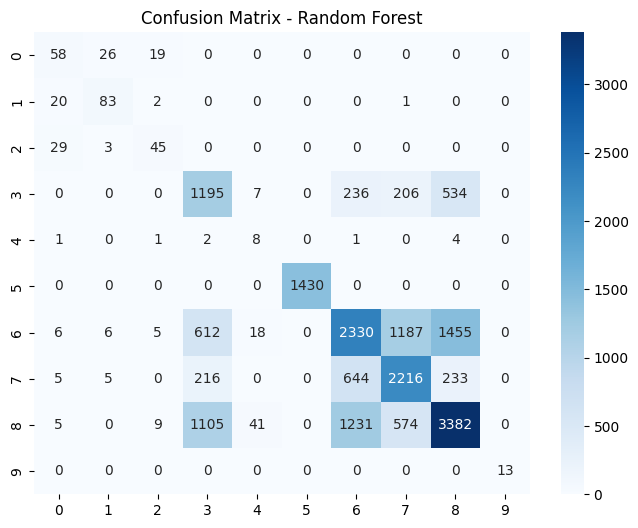

In [56]:
cm = confusion_matrix(y_test, rf_best.predict(X_test_scaled))

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Precision–Recall Curves

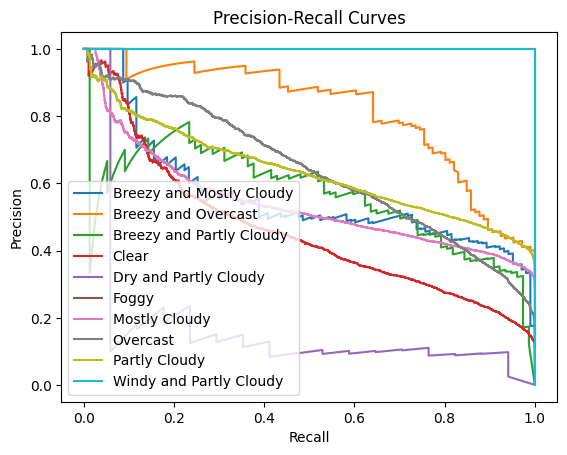

In [57]:
y_probs = rf_best.predict_proba(X_test_scaled)

for i in range(len(le.classes_)):
    precision, recall, _ = precision_recall_curve(y_test == i, y_probs[:, i])
    plt.plot(recall, precision, label=le.classes_[i])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title("Precision-Recall Curves")
plt.show()

# Feature Importance (Global Interpretability)

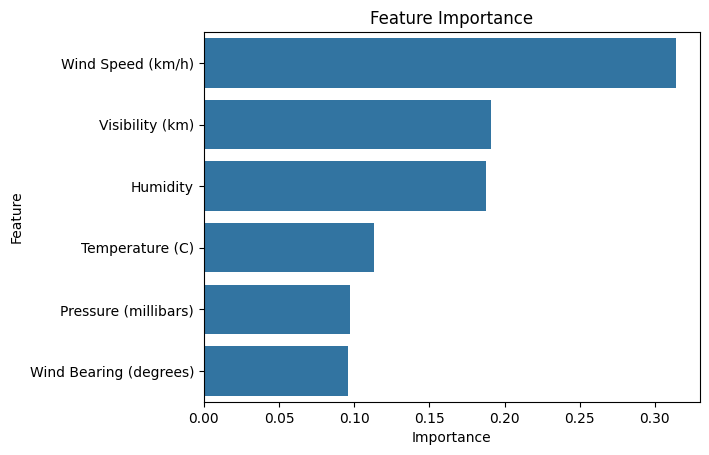

In [58]:
importance = rf_best.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

sns.barplot(data=feat_df, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()

# SHAP Explainability (Deep Interpretability)

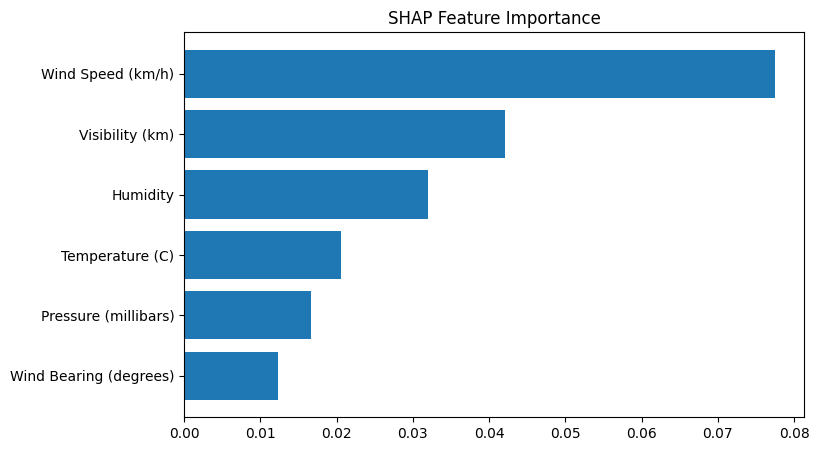

In [59]:


X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

X_sample = X_test_df.sample(200, random_state=42)

explainer = shap.TreeExplainer(rf_best)

# Get SHAP values
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_array = np.mean(np.abs(shap_values), axis=0)
else:
    shap_array = np.mean(np.abs(shap_values), axis=2)

# Compute mean importance per feature
feature_importance = np.mean(shap_array, axis=0)

# Create importance dataframe
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("SHAP Feature Importance")
plt.show()

# Save Model

In [60]:
import os

# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

In [62]:
import joblib

joblib.dump(rf_best, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model saved successfully ✅")

Model saved successfully ✅


In [63]:
from joblib import dump, load

dump(model, "best_model.pkl", compress=3)   # compression level 0–9

['best_model.pkl']

In [64]:
from joblib import dump, load

dump(model, "label_encoder.pkl", compress=3)   # compression level 0–9

['label_encoder.pkl']

In [65]:
from joblib import dump, load

dump(model, "scaler.pkl", compress=3)   # compression level 0–9

['scaler.pkl']

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import joblib

X = df.drop("Weather_Summary", axis=1)
y = df["Weather_Summary"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier())
])

pipeline.fit(X, y_encoded)

joblib.dump(pipeline, "best_model.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [68]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

df = pd.read_csv("weatherHistory.csv")

features = [
    "Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)",
    "Wind Bearing (degrees)",
    "Visibility (km)",
    "Pressure (millibars)"
]

df = df[features + ["Summary"]].dropna()

X = df[features]
y = df["Summary"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier())
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, "best_model.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']